# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [1]:
!pwd
!cd /content/
!git clone https://github.com/evgenkot/2025-Raschupkin-TimeSeriesCourse.git || echo present
!cd /content/2025-Raschupkin-TimeSeriesCourse
!git pull
!cd /content/2025-Raschupkin-TimeSeriesCourse/practice/05\ Snippets

/content
Cloning into '2025-Raschupkin-TimeSeriesCourse'...
remote: Enumerating objects: 302, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 302 (delta 30), reused 6 (delta 6), pack-reused 232 (from 2)
Receiving objects: 100% (302/302), 240.29 MiB | 11.66 MiB/s, done.
Resolving deltas: 100% (41/41), done.
Updating files: 100% (195/195), done.
fatal: not a git repository (or any of the parent directories): .git


In [2]:
import os

practice_dir_path = '/content/2025-Raschupkin-TimeSeriesCourse/practice/05 Snippets'
os.chdir(practice_dir_path)

Импорт библиотек и модулей

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

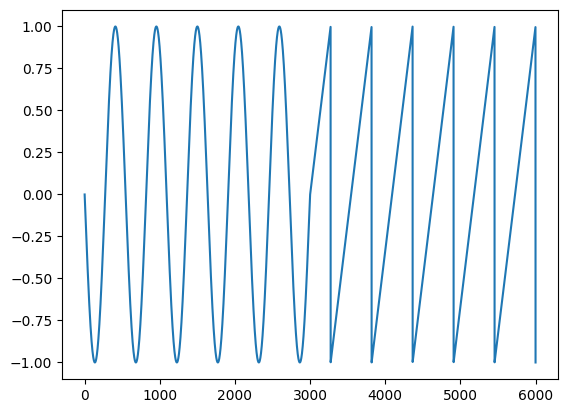

In [4]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [5]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


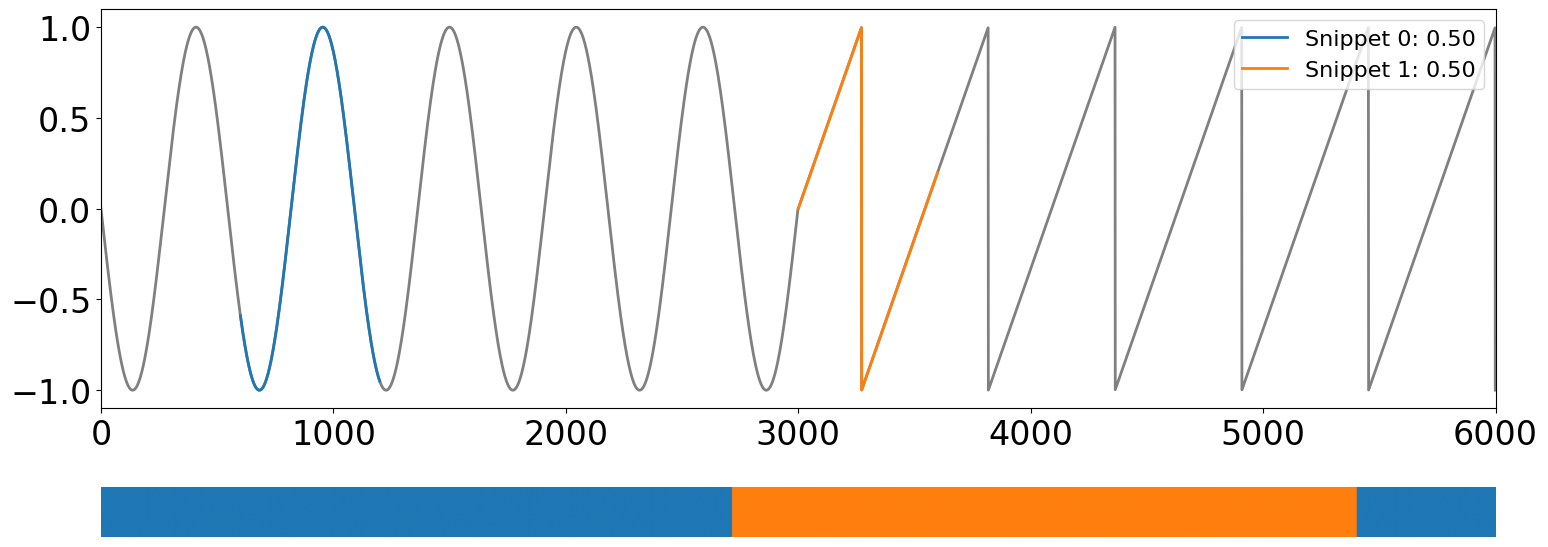

<Axes: >

In [6]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [7]:
pamap = np.loadtxt('./datasets/PAMAP/PAMAP.txt')

start = 1790
end = 1930

timestamp = pamap[0]
interval_mask = (timestamp >= start) & (timestamp <= end)

gyroscope = pamap[11][interval_mask]

In [8]:
snp = snippets(gyroscope, 600, 5, percentage=0.5)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

600


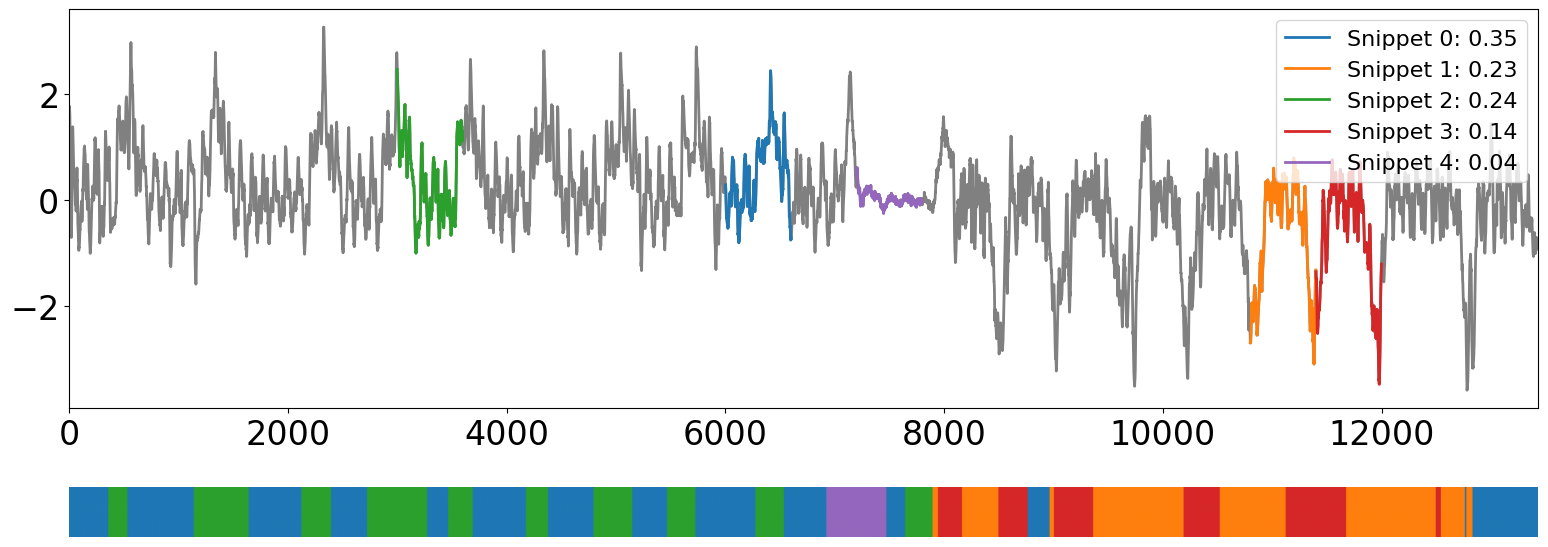

<Axes: >

In [9]:
plot_snippets(gyroscope, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [10]:
from sklearn.metrics import accuracy_score
activity_ids = pamap[1]
activity_ids = activity_ids[interval_mask]
activity_ids -= activity_ids.min()

snp_activity_ids = np.zeros(len(activity_ids))
for value, start, end in snp[-1]:
    snp_activity_ids[start:end] = value

accuracy = accuracy_score(activity_ids, snp_activity_ids)
print(f"accuracy: {accuracy*100:.2f}%")

accuracy: 53.16%


In [11]:
mx = np.arange(500, 1000, 100).astype(int)
kx = np.arange(1, 10, 1).astype(int)

mk_accuracies = []

for m in mx:
    for k in kx:
        snp = snippets(gyroscope, m, k, percentage=0.5)
        snp_activity_ids = np.zeros(len(activity_ids))
        for value, start, end in snp[-1]:
            snp_activity_ids[start:end] = value
        accuracy = accuracy_score(activity_ids, snp_activity_ids)
        mk_accuracies.append((m, k, accuracy))

mk_accuracies = np.array(mk_accuracies)
best_idx = np.argmax(mk_accuracies[:, 2])
best_m = mk_accuracies[best_idx, 0]
best_k = mk_accuracies[best_idx, 1]
best_accuracy = mk_accuracies[best_idx, 2]

In [12]:
import pandas as pd
import numpy as np

df_results = pd.DataFrame(mk_accuracies, columns=["m", "k", "accuracy"])
df_results = df_results.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
df_results["accuracy (%)"] = (df_results["accuracy"] * 100).round(2)

from IPython.display import display
display(df_results[["m", "k", "accuracy (%)"]])

,m,k,accuracy (%)
0,900.0,2.0,92.66
1,800.0,2.0,89.21
2,700.0,2.0,87.13
3,600.0,2.0,86.35
4,900.0,3.0,85.84
5,500.0,2.0,77.18
6,900.0,4.0,73.86
7,700.0,3.0,70.74
8,700.0,4.0,68.83
9,600.0,3.0,66.92


In [13]:
print(f"Best m: {best_m}, k: {best_k}, accuracy: {best_accuracy*100:.2f}%")

Best m: 900.0, k: 2.0, accuracy: 92.66%


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Алгоритм SnippetFinder успешно выделил характерные участки временного ряда: на искусственном сигнале он корректно различил участки синусоиды и пилообразной формы, а при анализе реальных данных PAMAP (канал гироскопа по оси Y) показал, что в интервале 1790–1930 секунд наблюдаются два устойчивых типа движения. Наилучшие результаты были получены при выборе параметров длины окна m = 900 и числа сниппетов k = 2, обеспечив точность классификации около 92.66%. Это подтверждает, что использование более длинного окна позволяет охватить полноценные циклы движения и снизить влияние шума, тогда как увеличение числа сниппетов или уменьшение длины окна приводит к переобучению и излишней фрагментации сигнала. Следовательно, выбранные параметры адекватно отражают реальную структуру движений и демонстрируют эффективность сниппет-подхода для выявления типичных паттернов в данных PAMAP без учителя.


### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

900


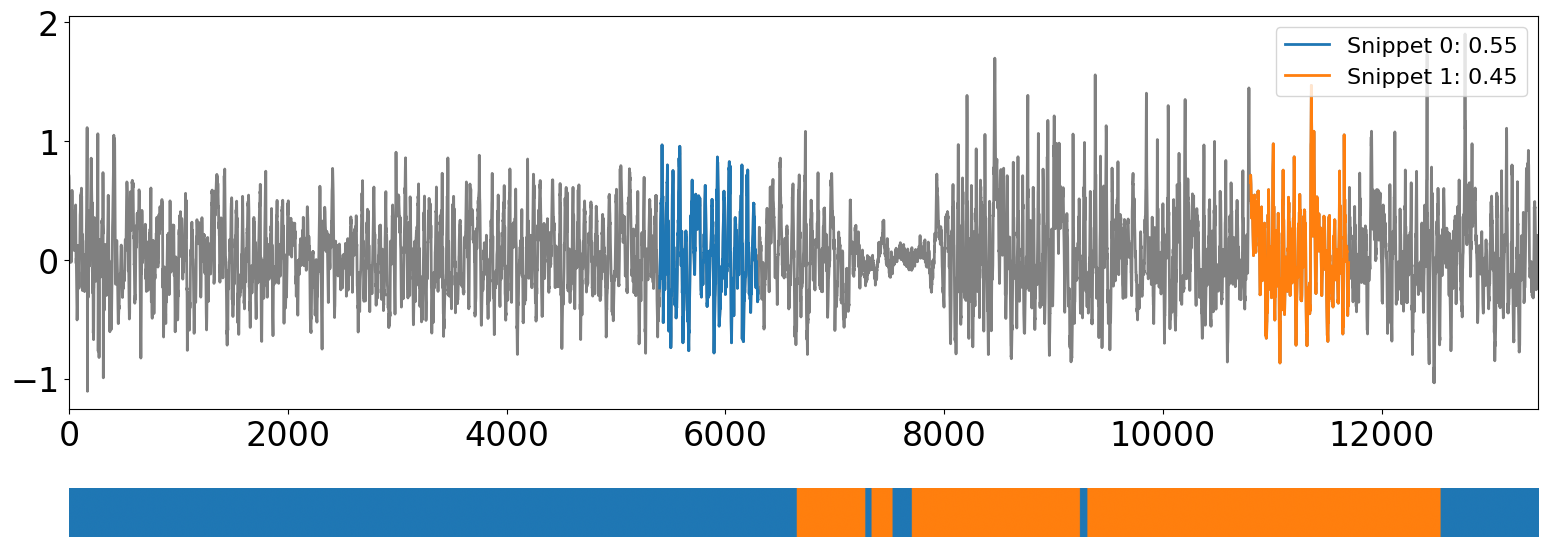

900


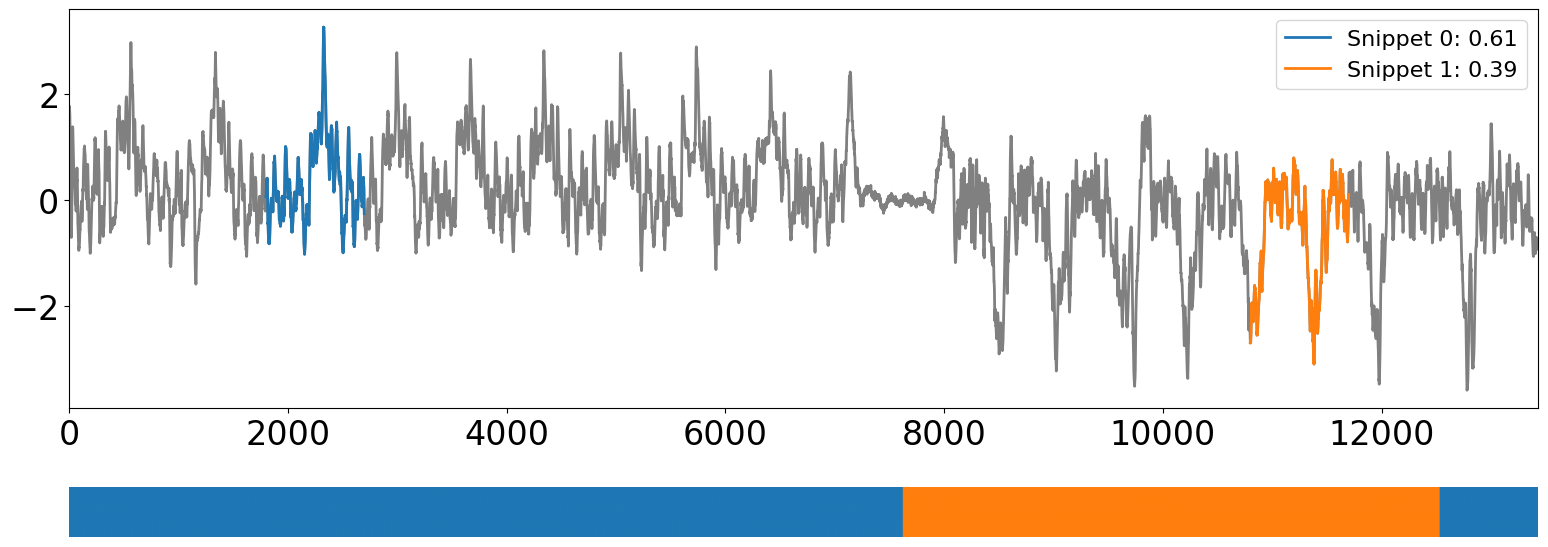

900


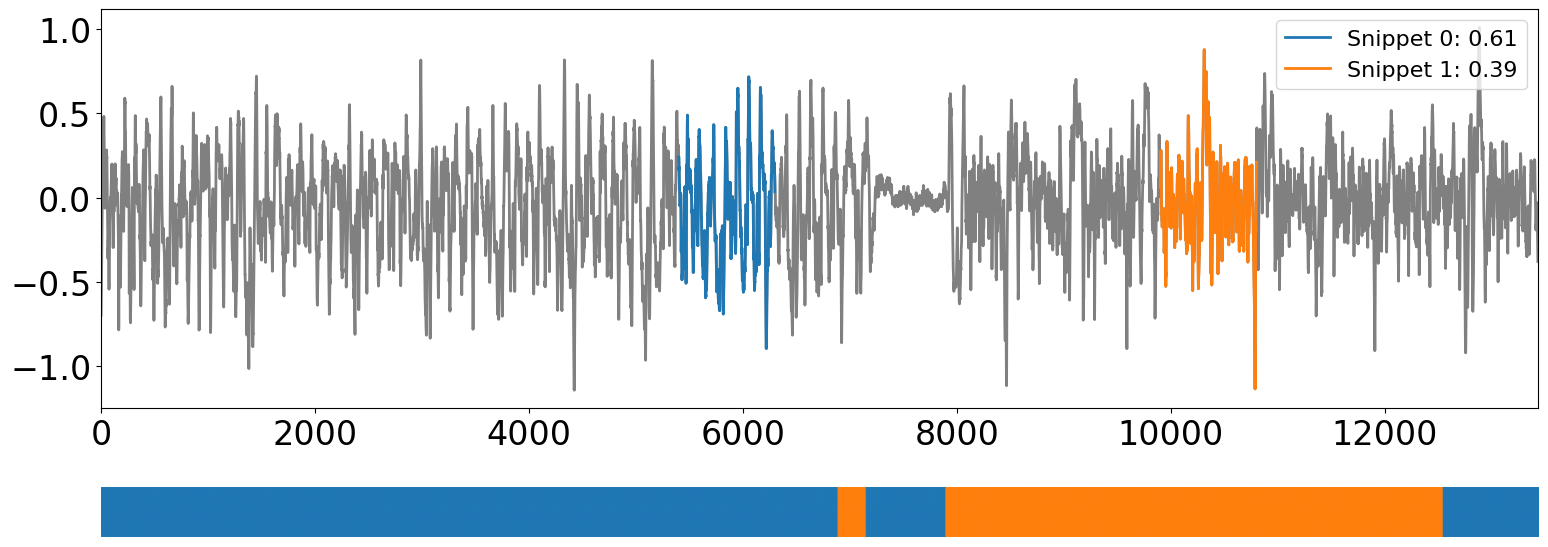

In [14]:
gyroscope_x = pamap[10][interval_mask]
snp_x = snippets(gyroscope_x, 900, 2, percentage=0.5)

plot_snippets(gyroscope_x, snp_x)

snp_activity_ids_x = np.zeros(len(gyroscope_x))
for value, start, end in snp_x[-1]:
    snp_activity_ids_x[start:end] = value


gyroscope_y = pamap[11][interval_mask]

snp_y = snippets(gyroscope_y, 900, 2, percentage=0.5)

plot_snippets(gyroscope_y, snp_y)

snp_activity_ids_y = np.zeros(len(gyroscope_y))
for value, start, end in snp_y[-1]:
    snp_activity_ids_y[start:end] = value


gyroscope_z = pamap[12][interval_mask]

snp_z = snippets(gyroscope_z, 900, 2, percentage=0.5)

plot_snippets(gyroscope_z, snp_z)

snp_activity_ids_z = np.zeros(len(gyroscope_z))
for value, start, end in snp_z[-1]:
    snp_activity_ids_z[start:end] = value

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [15]:

snp_activity_ids = []
for i in range(len(gyroscope_x)):
    votes = [snp_activity_ids_x[i], snp_activity_ids_y[i], snp_activity_ids_z[i]]
    snp_activity_ids.append(np.bincount(votes).argmax())

snp_activity_ids = np.array(snp_activity_ids)

accuracy = accuracy_score(activity_ids, snp_activity_ids)
print(f"{accuracy*100:.2f}%")



90.13%


❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

Объединение трёх осей и голосование по сниппетам дало более устойчивую разметку (90% accuracy): осевые ошибки компенсируются, границы становятся непрерывнее и лучше отражают реальные эпизоды. Каждая ось по-разному чувствует движения (X — около 6k и 10–12k, Y — 8–11k, Z — резкие пики к 11k), но в совокупности метод устойчив к ориентации датчика и шуму. Оставшиеся проблемы — небольшая инерция на переходах и редкие пропуски при слабых сигналах — связаны скорее с настройками окна и порога, чем с самим подходом.

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [17]:
m_opt = 900
k_max = 9

profile_areas = []
for i in range(3):
    gyroscope = pamap[10 + i][interval_mask]
    _, _, profiles, _, _, _ = snippets(gyroscope, m_opt, k_max, percentage=0.5)
    areas = [
        float(np.sum(np.min(profiles[:k], axis=0)))
        for k in range(1, k_max + 1)
    ]
    profile_areas.append(np.array(areas, dtype=float))

profile_areas = np.vstack(profile_areas).mean(axis=0)
profile_areas


array([199099.14447591, 158733.40335687, 142745.34545455, 127963.11703948,
       113634.4716273 , 100481.15658689,  88297.15896704,  76730.67147788,
        65747.12247647])

In [18]:
change = np.empty(profile_areas.shape, dtype=profile_areas.dtype)
change[0] = np.nan
change[1:] = profile_areas[:-1] / profile_areas[1:] - 1.0
change


array([       nan, 0.25429897, 0.11200406, 0.11551945, 0.12609418,
       0.1309033 , 0.13798856, 0.15074138, 0.16705749])

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

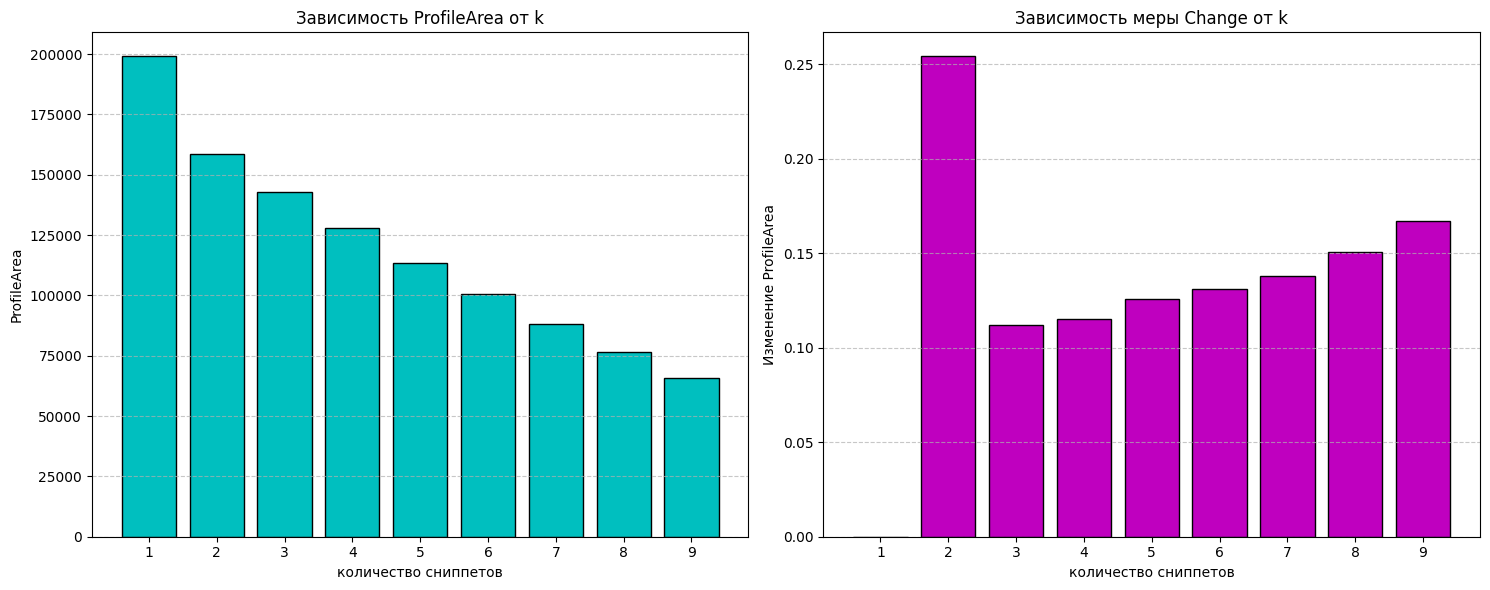

In [19]:
k_values = np.arange(1, k_max + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(k_values, profile_areas, color='c', edgecolor='black')
ax1.set_xticks(k_values)
ax1.set_xlabel("количество сниппетов")
ax1.set_ylabel("ProfileArea")
ax1.set_title("Зависимость ProfileArea от k")
ax1.grid(axis='y', linestyle='--', alpha=0.7)


ax2.bar(k_values, np.nan_to_num(change, nan=0.0), color='m', edgecolor='black')
ax2.set_xticks(k_values)
ax2.set_xlabel("количество сниппетов")
ax2.set_ylabel("Изменение ProfileArea")
ax2.set_title("Зависимость меры Change от k")
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?

Падение ProfileArea с ростом k показывает улучшение покрытия режимов сигнала, но главный скачок происходит при k=2 (≈+25%), что отражает появление второй доминирующей динамики. Дальнейшие приросты гораздо меньше и лишь уточняют границы без изменения структуры. Поэтому сигнал на выбранном интервале характеризуется двумя устойчивыми режимами, а оптимальное k — 2.